In [6]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:
df=pd.DataFrame({
    "study_hours":[1,2,3,4,5],
    "marks":[2,4,5,4,5]
})

In [8]:
df

,study_hours,marks
0,1,2
1,2,4
2,3,5
3,4,4
4,5,5


In [9]:
x=df[["study_hours"]]
y=df["marks"]

In [10]:
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [11]:
x_line=pd.DataFrame(
{
  "study_hours":np.linspace(x.min()[0],x.max()[0],100)  
}
)
y_line=model.predict(x_line)

In [12]:
x_line

,study_hours
0,1.000000
1,1.040404
2,1.080808
3,1.121212
4,1.161616
...,...
95,4.838384
96,4.878788
97,4.919192
98,4.959596


In [13]:
print("slope(m):",model.coef_[0])
print("intercept:",model.intercept_)

slope(m): 0.6000000000000002
intercept: 2.1999999999999993


In [14]:
x_new=pd.DataFrame({"study_hours":[4.0]})
y_new=model.predict(x_new)

In [15]:
print("predict value:",y_new)

predict value: [4.6]


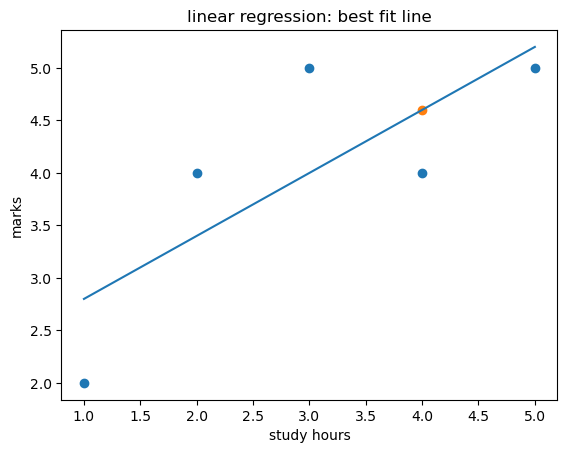

In [16]:
plt.figure()
plt.scatter(x,y)
plt.plot(x_line,y_line)
plt.scatter(x_new,y_new)
plt.xlabel("study hours")
plt.ylabel("marks")
plt.title("linear regression: best fit line")
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error
y_pred=model.predict(x)
mse=mean_squared_error(y,y_pred)
print("MSE:",mse)

MSE: 0.4799999999999998


# multi linear regression

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [19]:
df=pd.read_csv("MLR_Study_marks.csv")

In [20]:
df

,Study_Hours,Attendance,Sleep_Hours,Marks
0,2,60,5,48
1,3,62,5,50
2,4,65,6,55
3,5,68,6,58
4,6,70,6,60
...,...,...,...,...
72,6,79,6,68
73,7,82,7,71
74,8,85,7,75
75,9,88,7,78


In [21]:
x=df[["Study_Hours","Attendance","Sleep_Hours"]]
y=df["Marks"]

In [22]:
# train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [23]:
# step-4:train model
model=LinearRegression()
model.fit(x_train,y_train)
print("\nmodel intercept:",model.intercept_)
print("model coefficinets:",model.coef_)


model intercept: -0.28784910411806663
model coefficinets: [0.95830116 0.7505221  0.40445082]


In [24]:
# step-5:predictions
y_pred=model.predict(x_test)

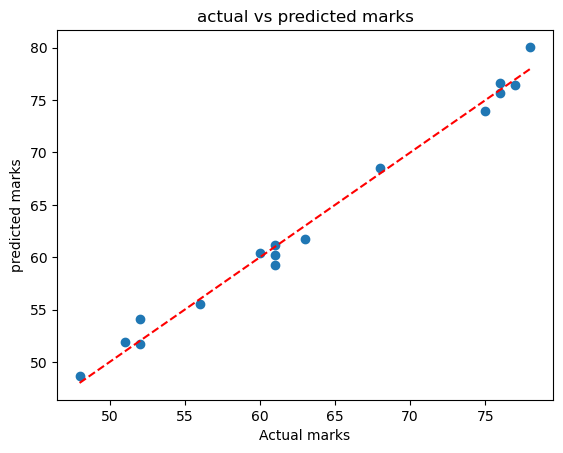

In [25]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual marks")
plt.ylabel("predicted marks")
plt.title("actual vs predicted marks")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], 'r--')
plt.show()

In [28]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Sqaured Error:", mse)
print("R^2 Score:", r2)



Mean Sqaured Error: 1.1326076728731718
R^2 Score: 0.9887157982387417


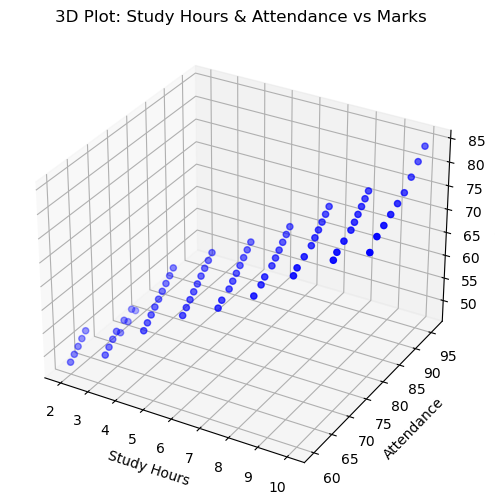

In [27]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df["Study_Hours"], df["Attendance"], df["Marks"], c='b', marker='o')
ax.set_xlabel("Study Hours")
ax.set_ylabel("Attendance")
ax.set_zlabel("Marks")
ax.set_title("3D Plot: Study Hours & Attendance vs Marks")
plt.show()
